Imports

In [ ]:
from collections import Counter
import json
import os
from pathlib import Path
import sys

current_dir = os.getcwd() 
parent_dir = os.path.dirname(current_dir)

if parent_dir not in sys.path:
    sys.path.append(parent_dir)

import matplotlib.pyplot as plt
import numpy as np
import rasterio
from sklearn.metrics import classification_report, confusion_matrix
import tifffile
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import models, transforms
from tqdm import tqdm

from ingestion import MultispectralTiffDataset



In [5]:
transform = transforms.Compose([
    transforms.Resize((224, 224))
])


Data Loader

In [ ]:

train_dir = "../data/train"
test_dir  = "../data/test"

train_dataset = MultispectralTiffDataset(train_dir, transform=transform)
test_dataset  = MultispectralTiffDataset(test_dir, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=4)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=4)


In [17]:
x, y = next(iter(train_loader))
print(x.shape)  # [B, 10, 224, 224]
print(y.unique())  # tensor([0,1])

torch.Size([32, 10, 224, 224])
tensor([0, 1])


Model Definition

In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [7]:
model = models.mobilenet_v3_large(
    weights=models.MobileNet_V3_Large_Weights.IMAGENET1K_V1
)


In [25]:
# Replace first conv to accept 10 bands
first_conv = model.features[0][0]
new_first_conv = nn.Conv2d(
    in_channels=10,
    out_channels=first_conv.out_channels,
    kernel_size=first_conv.kernel_size,
    stride=first_conv.stride,
    padding=first_conv.padding,
    bias=False
)
with torch.no_grad():
    new_first_conv.weight[:, :3] = first_conv.weight  # copy pretrained RGB weights
    if new_first_conv.in_channels > 3:
        nn.init.kaiming_normal_(new_first_conv.weight[:, 3:])  # init remaining bands

model.features[0][0] = new_first_conv

# Replace classifier head for 2 classes
model.classifier[3] = nn.Linear(model.classifier[3].in_features, 2)

Move model to device

In [26]:

model = model.to(device)


Class Imbalance, Optimizer & Scheduler

In [ ]:

# Count labels in training set
train_labels = [label for _, label in train_dataset.samples]
class_counts = Counter(train_labels)

print("Class counts:", class_counts)
# Expected:
# 0 -> Non-ASM
# 1 -> ASM

num_classes = 2
total_samples = len(train_labels)

# Compute inverse-frequency weights
class_weights = [
    total_samples / (num_classes * class_counts[i])
    for i in range(num_classes)
]

class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)

print("Class weights:", class_weights)

Class counts: Counter({1: 5096, 0: 2647})
Class weights: tensor([1.4626, 0.7597])


In [29]:
for i, w in enumerate(class_weights):
    print(f"Class {i} weight: {w}")


Class 0 weight: 1.4625991582870483
Class 1 weight: 0.7597135305404663


In [30]:

criterion = nn.CrossEntropyLoss(weight=class_weights)

Optimizer & Scheduler

In [ ]:
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-4,          
    weight_decay=1e-4 
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="max", factor=0.3, patience=3, min_lr=1e-6
)


Training Setup

In [ ]:
num_epochs = 30
stage1_epochs = 5  # Stage 1: only first conv + classifier
checkpoint_path = "mobilenetv3_checkpoint.pth"

In [ ]:
# Metrics
train_losses, train_accuracies, test_accuracies = [], [], []

# Resume from checkpoint

start_epoch = 0
if os.path.exists(checkpoint_path):
    print(f"🔁 Loading checkpoint from {checkpoint_path} ...")
    checkpoint = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    if 'scheduler_state_dict' in checkpoint:
        scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
    train_losses = checkpoint.get('train_losses', [])
    train_accuracies = checkpoint.get('train_accuracies', [])
    test_accuracies = checkpoint.get('test_accuracies', [])
    start_epoch = checkpoint['epoch'] + 1
    print(f"✅ Resumed from epoch {start_epoch}")


#Two Stage Fine Tuning Schedule
#Freeze first conv + classifier only for Stage 1

for param in model.parameters():
    param.requires_grad = False
for param in model.features[0][0].parameters():
    param.requires_grad = True
for param in model.classifier.parameters():
    param.requires_grad = True


🔁 Loading checkpoint from /Users/rosemaryakamagwuna/Documents/FAMM Project/FAMM/FAMM/models/mobilenetv3_checkpoint.pth ...
✅ Resumed from epoch 30


Training

In [ ]:
#  Training Loop

best_test_acc = 0.0
best_checkpoint_path = "mobilenetv3_best.pth"

for epoch in range(start_epoch, num_epochs):
    # Stage 2: unfreeze all layers
    if epoch == stage1_epochs:
        print("🔓 Switching to Stage 2: full fine-tuning")
        for param in model.parameters():
            param.requires_grad = True
        optimizer = torch.optim.Adam(model.parameters(), lr=1e-5)
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode="max", factor=0.3, patience=3, min_lr=1e-6
        )

    model.train()
    correct, total, loss_sum = 0, 0, 0

    for imgs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}"):
        imgs, labels = imgs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        loss_sum += loss.item() * imgs.size(0)
        _, preds = outputs.max(1)
        correct += preds.eq(labels).sum().item()
        total += labels.size(0)

    train_loss = loss_sum / total
    train_acc = correct / total
    train_losses.append(train_loss)
    train_accuracies.append(train_acc)

    # Evaluation
    model.eval()
    test_correct, test_total = 0, 0
    with torch.no_grad():
        for imgs, labels in test_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            _, preds = outputs.max(1)
            test_correct += preds.eq(labels).sum().item()
            test_total += labels.size(0)
    test_acc = test_correct / test_total
    test_accuracies.append(test_acc)

    # Scheduler step
    scheduler.step(test_acc)

    # Save BEST checkpoint

    if test_acc > best_test_acc:
        best_test_acc = test_acc
        torch.save({
            'epoch': epoch,
            'best_test_acc': best_test_acc,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
        }, best_checkpoint_path)

        print(f"🏆 New best model saved! Test Acc: {best_test_acc:.4f}")

    print(
        f"Epoch {epoch+1:02d} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Test Acc: {test_acc:.4f}"
    )

    # Save checkpoint
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_state_dict': scheduler.state_dict(),
        'train_losses': train_losses,
        'train_accuracies': train_accuracies,
        'test_accuracies': test_accuracies
    }, checkpoint_path)

Epoch 1/30: 100%|██████████| 242/242 [11:43<00:00,  2.91s/it]


🏆 New best model saved! Test Acc: 0.7199
Epoch 01 | Train Loss: 0.4645 | Train Acc: 0.7680 | Test Acc: 0.7199


Epoch 2/30: 100%|██████████| 242/242 [11:37<00:00,  2.88s/it]


🏆 New best model saved! Test Acc: 0.8660
Epoch 02 | Train Loss: 0.3881 | Train Acc: 0.8129 | Test Acc: 0.8660


Epoch 3/30: 100%|██████████| 242/242 [11:47<00:00,  2.93s/it]


...

Epoch 28 | Train Loss: 0.1024 | Train Acc: 0.9601 | Test Acc: 0.9170


Epoch 29/30: 100%|██████████| 242/242 [21:22<00:00,  5.30s/it]


Epoch 29 | Train Loss: 0.0891 | Train Acc: 0.9681 | Test Acc: 0.9177


Epoch 30/30: 100%|██████████| 242/242 [21:19<00:00,  5.29s/it]


Epoch 30 | Train Loss: 0.0968 | Train Acc: 0.9596 | Test Acc: 0.9184


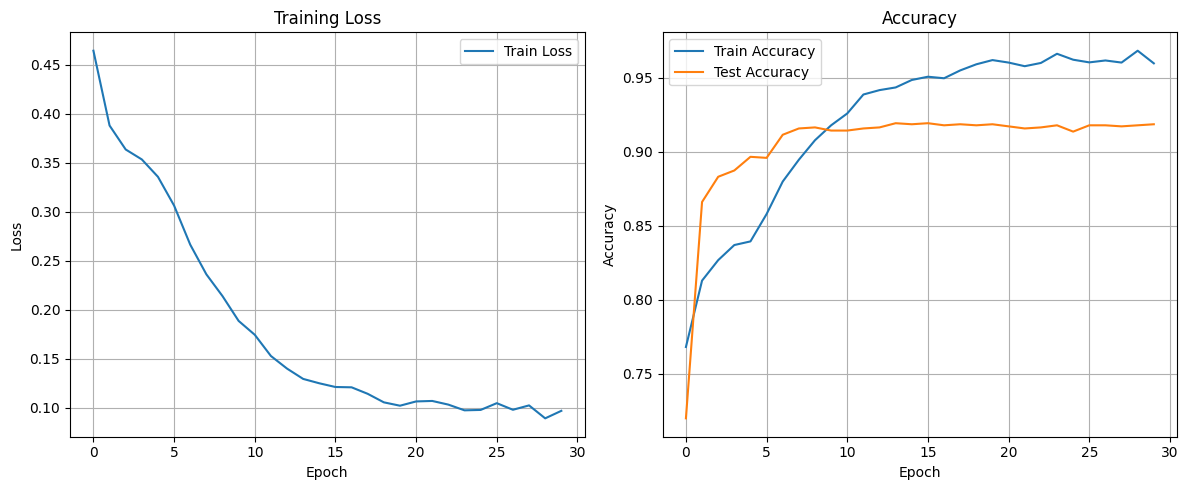

In [ ]:
# Plot Metrics

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label="Train Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label="Train Accuracy")
plt.plot(test_accuracies, label="Test Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()


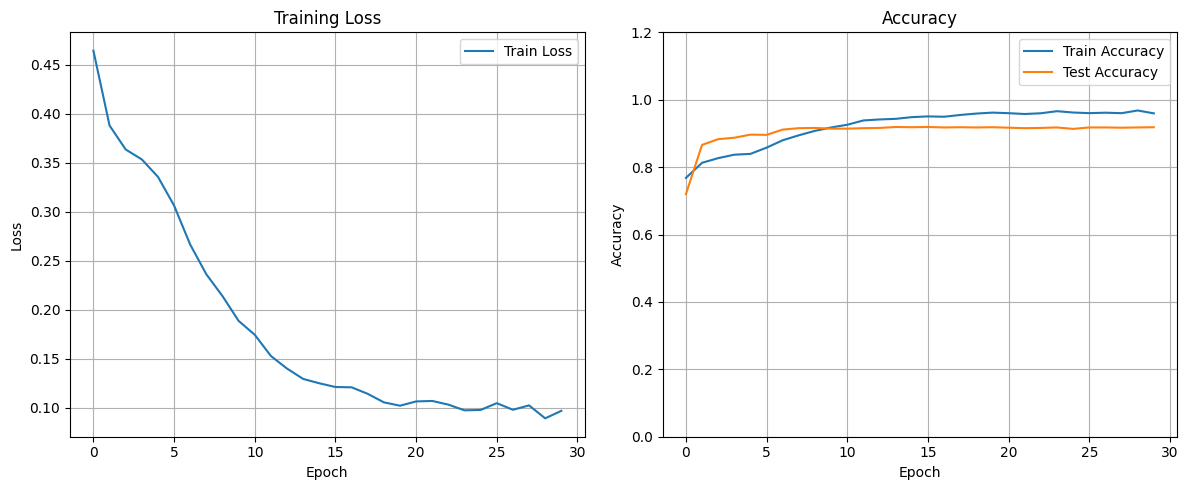

In [ ]:

# Plot Metrics

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label="Train Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label="Train Accuracy")
plt.plot(test_accuracies, label="Test Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.ylim(0, 1.2)
plt.show()


Logging Per-Band Importance (Gradient-Based Sensitivity)

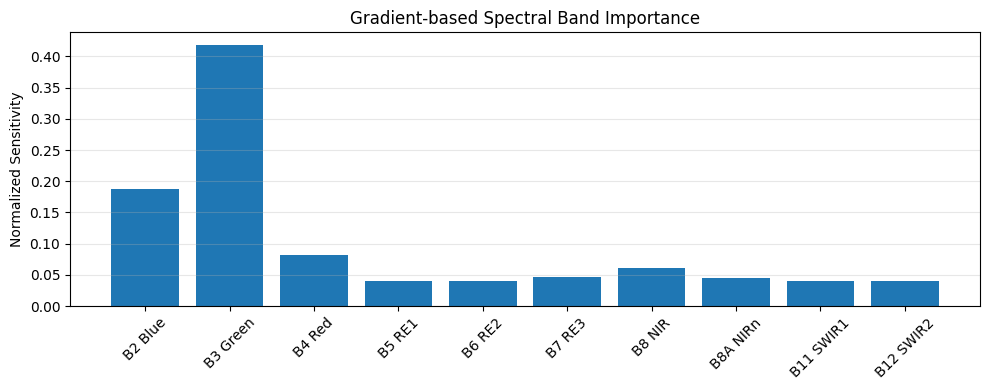

In [ ]:

#  Band Sensitivity

def compute_band_sensitivity(model, dataloader, device):
    model.eval()
    band_grads = torch.zeros(10).to(device)
    n = 0

    for imgs, labels in dataloader:
        imgs, labels = imgs.to(device), labels.to(device)
        imgs.requires_grad = True

        outputs = model(imgs)
        loss = torch.nn.functional.cross_entropy(outputs, labels)
        loss.backward()

        grads = imgs.grad.abs().mean(dim=(0, 2, 3))
        band_grads += grads
        n += 1
        if n == 50:
            break

    band_grads /= n
    band_grads /= band_grads.sum()
    return band_grads.detach().cpu()

model.eval()
band_importance = compute_band_sensitivity(model, test_loader, device)

# Plot
band_names = [
    "B2 Blue", "B3 Green", "B4 Red", "B5 RE1",
    "B6 RE2", "B7 RE3", "B8 NIR",
    "B8A NIRn", "B11 SWIR1", "B12 SWIR2"
]

plt.figure(figsize=(10, 4))
plt.bar(band_names, band_importance)
plt.ylabel("Normalized Sensitivity")
plt.title("Gradient-based Spectral Band Importance")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
y_true, y_pred = [], []

model.eval()
with torch.no_grad():
    for imgs, labels in test_loader:
        outputs = model(imgs.to(device))
        _, preds = outputs.max(1)
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

print(classification_report(y_true, y_pred)) #target_names=train_dataset.classes)
print(confusion_matrix(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.95      0.85      0.90       585
           1       0.90      0.97      0.93       825

    accuracy                           0.92      1410
   macro avg       0.92      0.91      0.91      1410
weighted avg       0.92      0.92      0.92      1410

[[496  89]
 [ 26 799]]


Checking False Positive Rate in Forest Reserves

In [ ]:
# CONFIG

# Path directly to the test folder
data_root = "../data/test"
geojson_path = "../data/ghana_asm_patch_metadata.geojson"
checkpoint_path = "../models/mobilenetv3_best.pth"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# LOAD GEOJSON

with open(geojson_path) as f:
    geojson = json.load(f)

features = geojson["features"]

# Filter: only forest reserve patches AND test images
forest_features = [
    f for f in features
    if f["properties"].get("in_forest_reserve", 0) == 1
    and "test_" in f["properties"].get("image_id", "")
]

print(f"Found {len(forest_features)} forest reserve patches in the test set.")


# LOAD MODEL (10-band)

model = models.mobilenet_v3_large(weights=None)

# Modify first conv layer for 10 bands
first_conv = model.features[0][0]
model.features[0][0] = nn.Conv2d(
    in_channels=10,
    out_channels=first_conv.out_channels,
    kernel_size=first_conv.kernel_size,
    stride=first_conv.stride,
    padding=first_conv.padding,
    bias=False
)

# Binary classifier
model.classifier[3] = nn.Linear(model.classifier[3].in_features, 2)

# Load checkpoint (weights only)
checkpoint = torch.load(checkpoint_path, map_location=device)
model.load_state_dict(checkpoint["model_state_dict"])
model.to(device)
model.eval()


# METRICS

evaluated = 0
skipped = 0
false_positives = 0


# EVALUATION LOOP

for feat in tqdm(forest_features, desc="Evaluating forest reserve patches"):
    props = feat["properties"]

    image_id = props["image_id"]  
    label = props["label"]        # 0 or 1

    # ASM / Non-ASM folder inside test folder
    class_folder = "1_ASM" if label == 1 else "0_Non-ASM"
    img_path = os.path.join(data_root, class_folder, f"{image_id}.tif")

    if not os.path.exists(img_path):
        print(f"⚠️ Missing image: {img_path}")
        skipped += 1
        continue

    # Read 10-band GeoTIFF
    try:
        with rasterio.open(img_path) as src:
            img = src.read().astype(np.float32)  # shape: (bands, H, W)
    except Exception:
        print(f"⚠️ Unreadable image: {img_path}")
        skipped += 1
        continue

    # Convert to torch tensor and add batch dimension
    img = torch.from_numpy(img).unsqueeze(0).to(device)  # (1, 10, H, W)

    # Forward pass
    with torch.no_grad():
        output = model(img)
        pred = torch.argmax(output, dim=1).item()

    evaluated += 1

    # False positive = predicted ASM (1) inside forest reserve
    if pred == 1:
        false_positives += 1


# RESULTS

print("\n===== Forest Reserve Evaluation (Test Data Only) =====")
print(f"Evaluated patches (images found):       {evaluated}")
print(f"Skipped patches (missing/unreadable):  {skipped}")
print(f"False positives (ASM predicted):        {false_positives}")

if evaluated > 0:
    fp_rate = false_positives / evaluated * 100
    print(f"False positive rate: {fp_rate:.2f}%")
else:
    print("False positive rate: N/A (no evaluated samples)")



Found 345 forest reserve patches in the test set.


Evaluating forest reserve patches: 100%|██████████| 345/345 [00:28<00:00, 12.26it/s]



===== Forest Reserve Evaluation (Test Data Only) =====
Evaluated patches (images found):       345
Skipped patches (missing/unreadable):  0
False positives (ASM predicted):        62
False positive rate: 17.97%


Test on 2025 Files

In [ ]:
test_dir1  = "../data/2025_data/test"

test_dataset1  = MultispectralTiffDataset(test_dir1, transform=transform)

test_loader1  = DataLoader(test_dataset1, batch_size=500, shuffle=False, num_workers=4)


In [13]:
x, y = next(iter(test_loader1))
print(x.shape)  # [B, 10, 224, 224]
print(y.unique())  # tensor([0,1])

torch.Size([500, 10, 224, 224])
tensor([0])


In [ ]:
# Load checkpoint

checkpoint_path = "../models/mobilenetv3_best.pth"  # <-- update this

checkpoint = torch.load(checkpoint_path, map_location=device)
model.load_state_dict(checkpoint["model_state_dict"])
model.to(device)
model.eval()

# Evaluate

y_true, y_pred = [], []

with torch.no_grad():
    for imgs, labels in test_loader1:
        imgs = imgs.to(device)
        labels = labels.to(device)

        outputs = model(imgs)
        preds = torch.argmax(outputs, dim=1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())


# Metrics

if len(y_true) == 0:
    print("⚠️ No samples found in test_loader1")
else:
    print(classification_report(y_true, y_pred))
    print(confusion_matrix(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.97      0.74      0.84       585
           1       0.84      0.98      0.91       825

    accuracy                           0.88      1410
   macro avg       0.90      0.86      0.87      1410
weighted avg       0.89      0.88      0.88      1410

[[430 155]
 [ 14 811]]
